# Oppgave 1 Logistisk befolkningsvekst

I dette programmet ønsker jeg å ta utgangspunkt i ulike land sine nåværende data om befolkningsvekst (i prosent) og befolkningstall, og basert på dette simulere én mulig utvikling av disse landene de kommende 20 årene. Tallene er hentet fra verdensbanken, og jeg bruker data fra 2022. Jeg ønsker også at jeg bare skal få opp ett land om gangen, da det er enklere å lese for brukeren av programmet.

For å kunne bruke den logistiske ligningen som brukt ved oppgave 1 og 2 i timene, trenger vi en makspopulasjon for landene også. Denne kan vi ikke vite nøyaktig, så her har jeg bare antatt noen makspopulasjoner. I tillegg har jeg antatt at vekstprosentene holder seg like som den var i 2022, men dette er litt urealistisk, for den er vanligvis litt forskjellig fra år til år siden denne er basert på (imigrasjon + fødselstall) - (emigrasjon + dødstall).

Velg et land fra listen for å få befolkningsveksten til landet:

Norge

Sverige

Finland

Nederland

...

Niger


Skriv inn landet: Niger


Niger har følgende data; startpopulasjon: 26210000, vekstrate: 0.037 og makspopulasjon 40000000

Befolkningen har endret seg med 5763747 personer, og dette er en totalendring på 21.99% i populasjonen

Niger har ved denne modellen en populasjon på 31973747 i 2042

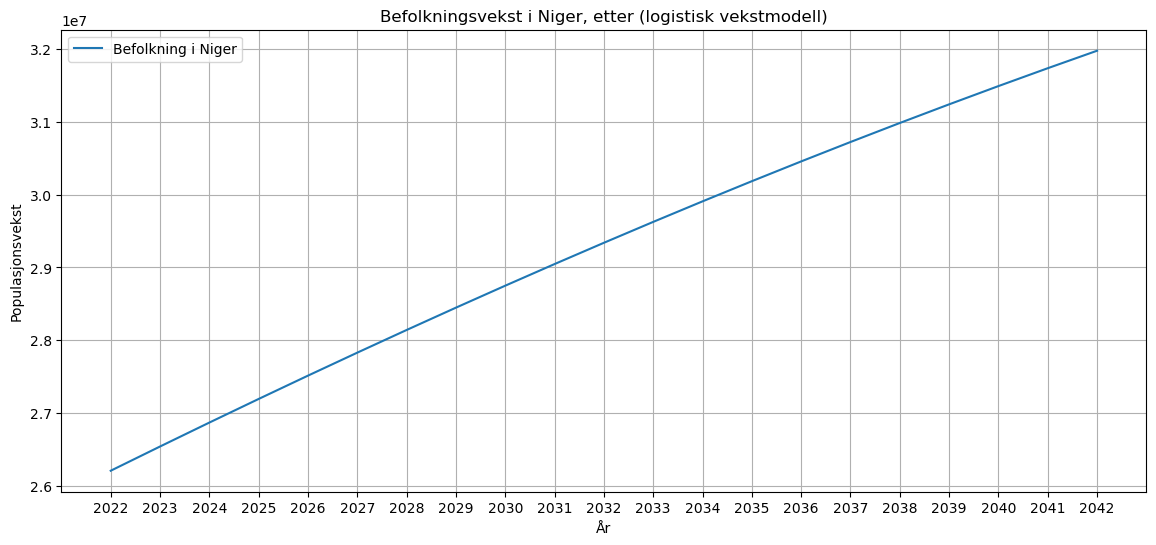

In [3]:
#Importerer (og installerer) det jeg trenger for å gjennomføre utregninger, plotting og "estetisk printing"
import matplotlib.pyplot as plt
import numpy as np
import math
e=math.exp(1)
!pip install rich   
from rich import print


start_år=2022
år=20   #Antall år jeg vil simulere


#Landene i programmet har informasjonen til nevnte land inne i dictionaries for hvert land, (dictionaries med landene sine data inne i en dictionary for land generelt)
Land={
    "Norge": {"start_populasjon": 5457000, "vekstrate": 0.009, "maks_populasjon": 10000000},
    "Sverige": {"start_populasjon": 10564000, "vekstrate": 0.007, "maks_populasjon": 17000000},
    "Finland": {"start_populasjon": 5556000, "vekstrate": 0.003, "maks_populasjon": 13000000},
    "Nederland": {"start_populasjon": 17700000, "vekstrate": 0.01, "maks_populasjon": 22000000},
    "Amerika": {"start_populasjon": 333300000, "vekstrate": 0.004, "maks_populasjon": 1000000000},
    "Canada": {"start_populasjon": 38930000, "vekstrate": 0.018, "maks_populasjon": 70000000},
    "India": {"start_populasjon": 1417000000, "vekstrate": 0.007, "maks_populasjon": 2000000000},
    "Kina": {"start_populasjon": 1412000000 ,"vekstrate": 0,  "maks_populasjon": 2000000000},
    "Japan": {"start_populasjon": 125100000, "vekstrate": (-0.004), "maks_populasjon": 145000000},
    "SørAfrika": {"start_populasjon": 59890000, "vekstrate": 0.008, "maks_populasjon": 150000000},
    "Niger": {"start_populasjon": 26210000, "vekstrate": 0.037, "maks_populasjon":40000000}
}

#Funksjon som bruker den logistiske likningen og regner ut populasjonsveksten utifra de gitte variablene som befinner seg i dictionaries over 
#Funksjonen i seg selv har her ikke variablene til landene fra dictionaries, dette blir en generell utregningsfunksjon som jeg kan kalle på senere 
#Utregningene går for hvert år (for-løkken iterer) og blir lagt inn i ei liste som jeg så kan bruke til å plotte populasjonsveksten over tid senere
def populasjonsvekst(start_populasjon, vekstrate, maks_populasjon, år):
    A=(maks_populasjon-start_populasjon)/start_populasjon
    populasjoner=[]

    for t in range(år + 1):
        P=maks_populasjon/(1+A*e**(-vekstrate*t))
        populasjoner.append(P)
    return populasjoner

#Denne funksjonen printer først ut instruksjonen til bruker, og oppgir de mulige valgene ved å printe navnekeysene til land-dictionarien 
#Deretter reagerer funksjonen en av to måter når bruker skriver inn informasjon; enten ved landet som er skrevet inn er gyldig og returnerer dette
#eller ved at det ikke er gyldig, informerer bruker om dette, for så å starte funksjonen på nytt fra start i håp om å få en gyldig input
def brukervalg_land():
    print("Velg et land fra listen for å få befolkningsveksten til landet:")
    for land in Land.keys():
        print(land)

    valgt_land=input("\nSkriv inn landet:")

    if valgt_land in Land:
        return valgt_land
    else:
        print("Dette landet er ikke med i programmet, velg ett land fra denne listen:")
        return brukervalg_land()

#Dette er funksjonen som "trekker lasset" i dette skriptet. Her kaller funksjonen først på "brukervalg_land"-funksjonen som "program"-funksjonen så 
#kan bruke til å få vite hvilket land den skal hente data fra gjennom å kalle på disse med key-verdiene til dictionarien.
#Deretter kaller funksjonen på "populasjonsvekst"-funksjonen for å bruke denne til å regne ut populasjonsveksten med det nå valgte landet. 
def program():
    valgt_land=brukervalg_land()   #Bruker velger et land
    
    #Henter så dataene for dette valgte landet fra dictionaries øverst i cellen
    land_info=Land[valgt_land]
    start_populasjon=land_info["start_populasjon"]
    vekstrate=land_info["vekstrate"]
    makspopulasjon=land_info["maks_populasjon"]
    populasjoner=populasjonsvekst(start_populasjon, vekstrate, makspopulasjon, år)
    

    #Enkle utregninger som jeg vil skal komme med når brukeren får resultatene til landet
    slutt_populasjon=populasjoner[-1]                           #Populasjonen i 2040 når simuleringen er ferdig (siste element i listen)
    befolkningsendring=slutt_populasjon - start_populasjon      
    prosentendring=(befolkningsendring/start_populasjon)*100

    #Printer dataene som er i dictionarien til det landet brukeren har valgt, befolkningsendring og sluttpopulasjonen i 2042
    #Her har jeg også brukt biblioteket rich som jeg har installert og importert tidligere for å få fet skrift og farge på skriften jeg printer ut.
    print("\n")       #Linjeskift for at input og output lettere kan skilles for bruker
    print(f'[bold blue]{valgt_land} har følgende data; startpopulasjon: {start_populasjon}, vekstrate: {vekstrate} og makspopulasjon {makspopulasjon}[/bold blue]')
    print(f'[bold blue]Befolkningen har endret seg med {befolkningsendring:.0f} personer, og dette er en totalendring på {prosentendring:.2f}% i populasjonen[/bold blue]')
    print(f'[bold blue]{valgt_land} har ved denne modellen en populasjon på {slutt_populasjon:.0f} i 2042[/bold blue]')
    

    #Plotter landets befolkningsvekst over de 20 kommende årene
    årstall=np.arange(start_år, start_år + år + 1)
    plt.figure(figsize=(14, 6))
    plt.plot(årstall, populasjoner, label=f'Befolkning i {valgt_land}')
    plt.xlabel('År')
    plt.ylabel('Populasjonsvekst')
    plt.title(f'Befolkningsvekst i {valgt_land}, etter (logistisk vekstmodell)')
    plt.grid()
    plt.legend()
    
    
    x_akse = np.arange(start_år, start_år + år + 1, 1)
    plt.xticks(ticks = x_akse)
    plt.show()

#Dette er et kall til funksjonen med samme navn, som starter funksjonen og med dette også starter selve programmet grunnet måten det er skrevet på
program()


### Diskusjon og forklaring av oppgave 1

I dette programmet ønsket jeg å ta i bruk innebygde funksjoner og biblioteker i python som vi har lært om i timene, og anvende dette på en måte som både ligner på måten vi allerede har løst oppgavene, men med noe nytt. Jeg har kommentert mye av hva jeg har gjort inne i koden, så der finner en forklaringer på hva jeg har gjort og hvordan f.eks de ulike funksjonene henger sammen. I programmet har jeg valgt å bruke dictionaries på landene for å samle informasjonen, her kunne jeg liksågodt brukt for eksempel lister men da måtte jeg brukt indekser istedenfor tekststrenger for å "hente" verdiene fram, og det hadde vært mindre tydelig hva hvert av tallene i listen representerte. Eller så kunne jeg kanskje lagret informasjonen i flere lister og brukt zip lister for å sy dem sammen til tupler, men dette syns ihvertfall jeg er en mer (enn nødvendig) komplisert måte å gjøre det på.

Måten programmet er satt opp på gjør det mulig for brukeren bare å velge hvilket land det vil ha info fra, blandt en oppgitt liste som finnes i programmet, for så å få all relevant info om befolkningsvekst servert. Her får brukeren både utregnede verdier pent fremvist og et lineært diagram som visuelt viser befolkningsveksten over tid.

Jeg syns det var vanskelig å skille den tidligere printede teksten fra input-delen av programmet, så da tok jeg meg en liten tur på nett og fant ut at rich biblioteket både hadde farger og tekstformateringer som kunne hjelpe meg med å printe tekst både penere og tydeligere. Jeg havnet ned i ett lite kaninhull med ulike måter å gjøre dette på, som å bruke hele ANSI escape koder (ikke gøy å skrive eller lese) og installering av termcolor (som jeg fant ut bare ga meg farger). Så for mitt bruk var rich-biblioteket definitivt det beste valget (og så enkelt og kjekt å bruke).

Programmet er per nå  begrenset til 20 år og grafene viser da ikke det vi typisk kjenner som logistiske funksjoner siden dette ikke er lang nok tid til at dét kommer til uttrykk. Dette er en global variabel som en lett kan endre på til si 150 år, som da vil gjøre det tydelig i grafene at det er en logistisk modell som er anvendt her. 

# Oppgave 2 Sparekalkulator

Denne oppgaven handler om sparekalkulator
Kan få med om :
* Inntekt
* Kostnad
* Sparing
* Sparemål
* Dersom jeg tar opp lån hvor mye må jeg ha til lån og hvor mye må jeg betale i renter og avdrag og hvor lenge jeg må spare når jeg kun har sommerjobb og har studielån i fond

Hva jeg skal svare på:
Jeg ønsker å kjøpe leilighet til 3 millioner kr. Jeg starter i 2020 med å spare i BSU konto hvor max grensen er 27 500 i året. Man må ha 15% egenkapital før man får lån

a) Hvor mange år vil det ta før jeg får lån hvis jeg setter inn månedlig på BSU(15% egenkapital)?

b) Hvor mye må jeg spare dersom jeg skal bli ferdig å spare til EK innen 2030?

Egenkapitalen jeg trenger er 450000.0 kr og lånebeløpet blir da 2550000.0 kr

Det vil ta 11 år før jeg har nok egenkapital til å få lån

Her er listen over årlig sluttsum på BSU konto:,[40396.182502908974, 82707.51821517444, 125055.3760547643, 
167412.78066615263, 209774.0739180555, 252137.33132197257, 294501.71847082884, 336866.8149610666, 
379232.38595985476, 421598.2899900288, 463964.43673292873]

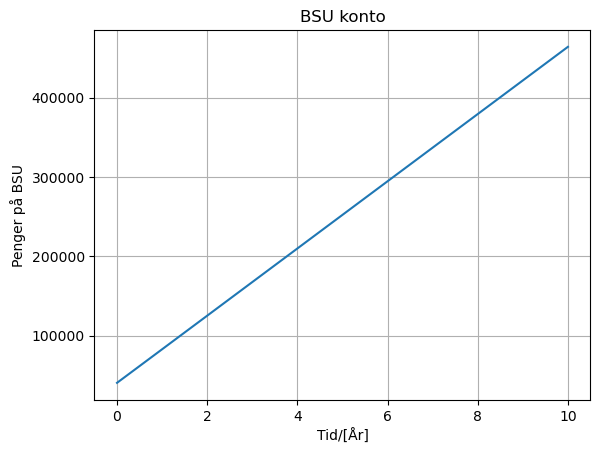

In [4]:
import math
import matplotlib.pyplot as plt
# Hvor mange år vil det ta før jeg får lån?
#Definere variabler
BSU = 27500/12 
r = 0.0675 #Renter
n=12
p = 3000000 #Pris for leilighet
t = 0
saldo = 0


#Formler og løkker
ek = p*0.15
lanebelop = p - ek

UB_sparekonto = []
def forrentning (BSU,r,n,t):
    saldo = BSU*((1+(r/n))**(n*t)-1)/(r/n)
    return saldo

while saldo<ek:
    t =t+1
    saldo = forrentning(BSU,r,t,n)
    UB_sparekonto.append(saldo)


#Print
print("Egenkapitalen jeg trenger er", ek, "kr og lånebeløpet blir da", lanebelop, "kr")
print(f"Det vil ta {t} år før jeg har nok egenkapital til å få lån")
print(f"Her er listen over årlig sluttsum på BSU konto:,{UB_sparekonto}")

#Graf
plt.plot(UB_sparekonto)
plt.title("BSU konto")
plt.xlabel("Tid/[År]")
plt.ylabel("Penger på BSU")
plt.grid()
plt.show()

År 2020: 35714.74 kr og Renter dette året: 1607.16 kr
År 2021: 73036.64 kr og Renter dette året: 3286.65 kr
År 2022: 112038.03 kr og Renter dette året: 5041.71 kr
År 2023: 152794.49 kr og Renter dette året: 6875.75 kr
År 2024: 195384.98 kr og Renter dette året: 8792.32 kr
År 2025: 239892.04 kr og Renter dette året: 10795.14 kr
År 2026: 286401.93 kr og Renter dette året: 12888.09 kr
År 2027: 335004.75 kr og Renter dette året: 15075.21 kr
År 2028: 385794.71 kr og Renter dette året: 17360.76 kr
År 2029: 438870.21 kr og Renter dette året: 19749.16 kr


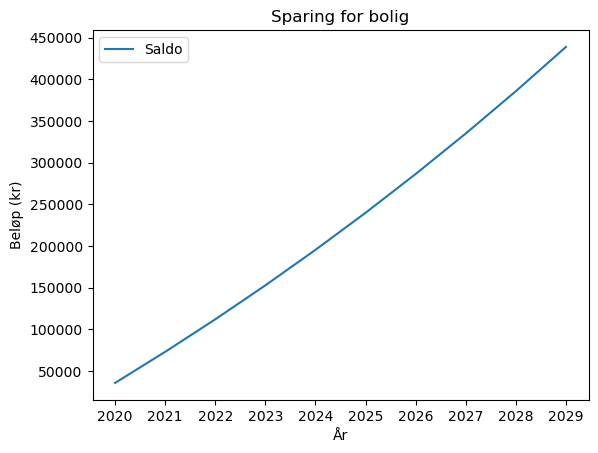

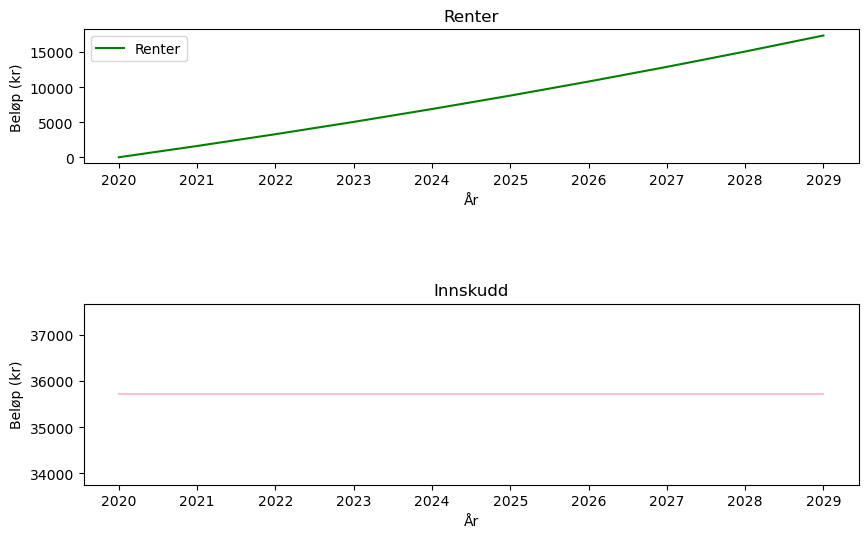

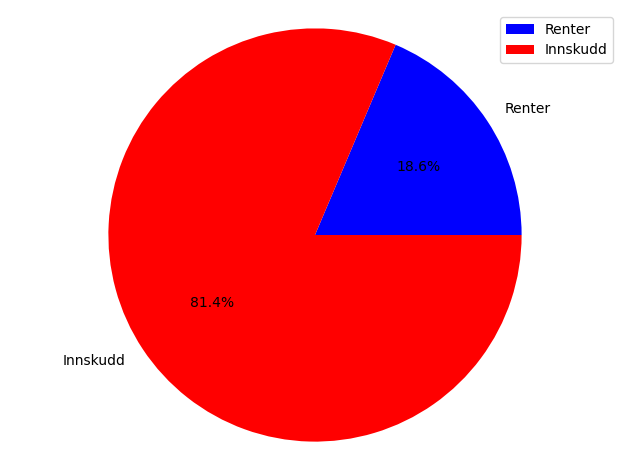

In [6]:
# b) Dersom jeg vil flytte ut til 2030, hvor mye må jeg ha som innskudd og hvor mye blir renter?
import matplotlib.pyplot as plt

#Variabler
renter = 0.045
startaar = 2020
sluttaar = 2030 
n = 12 
p = 3000000
IB_saldo = 0
EK = 450000 #Som jeg fant ut i a, trenger jeg 450 000 i EK for å ha 15%. 
aar = list(range(startaar, sluttaar))
t = sluttaar - startaar

def manedlig_og_aarlig_innskudd(EK,renter,n,t):
    liste_manedlige_innskudd = []
    liste_arlig_innskudd = []
    innskudd_manedlig = EK /(((1+renter/n)**(n*t)-1)/(renter/n))
    innskudd_aarlig = innskudd_manedlig*n
    for indeks in range(0,t):
        liste_manedlige_innskudd.append(innskudd_manedlig)
        liste_arlig_innskudd.append(innskudd_aarlig)
    return liste_manedlige_innskudd, liste_arlig_innskudd


saldo_aarlig = []
renter_aarlig = []
saldo = IB_saldo
innskudd_manedlig, innskudd_aarlig = manedlig_og_aarlig_innskudd(EK,renter,n,t) 

for ar in range(0,t):
    renter_opptjent = saldo * renter
    saldo += renter_opptjent + innskudd_aarlig[ar]
    renter_opptjent2 = saldo*renter
    #print(saldo)
    saldo_aarlig.append(saldo)
    renter_aarlig.append(renter_opptjent)

    print(f"År {startaar + ar}: {saldo:.2f} kr og Renter dette året: {renter_opptjent2:.2f} kr")


def resultater(saldo_aarlig, innskudd_manedlig, innskudd_aarlig, renter_aarlig, t):
    sluttverdi = saldo_aarlig[-1] + renter_aarlig[-1] 
    total_innskudd = sum(innskudd_aarlig)
    total_rente = sum(renter_aarlig)
    renter_prosent = (total_rente/sluttverdi) * 100
    innskudd_prosent = (total_innskudd/sluttverdi) * 100
    return renter_prosent, innskudd_prosent

renter_prosent, innskudd_prosent = resultater(saldo_aarlig, innskudd_manedlig, innskudd_aarlig, renter_aarlig, t)

#Plotting i graf
plt.subplot(1,1,1)
plt.plot(aar,saldo_aarlig, label="Saldo")
plt.title("Sparing for bolig")
plt.xlabel("År")
plt.xticks(aar)
plt.ylabel("Beløp (kr)")
plt.legend()

plt.figure(figsize=(10,8))
plt.subplot(4,1,2)
plt.plot(aar,renter_aarlig, label="Renter", color = "green")
plt.title("Renter")
plt.xlabel("År")
plt.xticks(aar)
plt.ylabel("Beløp (kr)")
plt.legend()

plt.subplot(3,1,3)
plt.plot(aar,innskudd_aarlig, label="Innskudd", color = "pink")
plt.title("Innskudd")
plt.xlabel("År")
plt.xticks(aar)
plt.ylabel("Beløp (kr)")

plt.figure()
plt.pie([renter_prosent, innskudd_prosent], labels = ["Renter", "Innskudd"] , colors = ["blue","red"], autopct = "%1.1f%%")
plt.axis("equal")

plt.tight_layout()
plt.legend()
plt.show()


### 

a) Fremgangsmåte: Starter med å definere variabler som blir relevante alt med utgangspunkt i år. Deler BSU årlig beløp for å finne det månedlige beløpet. Renten er tatt utgangspunkt i virkelig verdi. Deretter starter jeg med selve kodingen. Starter først med å finne ut hva jeg faktisk trenger i EK og hva lånebeløpet er. Dette er også den første printen, hvor jeg brukte helt basic fremgangsmåte. Så lager jeg en tom liste som skal reflektere hva jeg vil ha på konto ved utgangen av året. Jeg definerer forrentning og legger inn formelen for dette inni definisjonen. Til slutt returnerer jeg saldoen.

Siden mitt spm handler om hvor lang tid det vil ta, bruker jeg en while løkke slik at den stopper når den kommer det beløpet den trenger (450 000). I løkken legger jeg til tiden (t) og legger til et år fordi jeg satt den til 0 som start. Saldoen som ble definert tidligere kommer i løkken og til slutt legger jeg til saldo formelen i UB sparekonto for at den skal bruke formelen når den regner. Printer her både hvor lang tid det vil ta ved hjelp av en f streng. La til en tillegg print hvor man kan se utviklingen fra år til år over hvor mye jeg vil ha på BSU kontoen. Legger også til graf for å vise fremgangen. Her bruker jeg vanlig "plot" for å kun vise en rett linje.

b) Fremgangsmåte: Starter igjen med å definere variabler og har også tatt med verdien av EK som jeg fant i a). Rentene har jeg tatt litt lavere fordi jeg vet jeg har max 10 år på sparingen og da må jeg spare mer og BSU tillater ikke dette. Derfor vil jeg i denne oppgaven spare på sparekonto, men de har også lavere rente. Deretter setter jeg inn en funksjon ved å definere månedlige og årlige innskudd ved bruk av formler og returnerer dem. Deretter lager jeg tomme lister for saldo og renter siden de vil variere fra år til år. Bruker ei for løkke for å finne .... Lager også en funksjon for å definere resultatene jeg vil ha med. Først legger jeg til formlene for de punktene jeg ønkser og deretter printer jeg alt av resultat. Til slutt lager jeg en graf hvor jeg plotter både saldoen, årlig innskudd og årlige renter.

TOTALT: Analyse av resultater på a og b: Som vi kan se vil jeg ha et større månedlig innskudd og årlige innskudd ved å spare kun på sparekonto i 10 år. Dette er jo naturlig siden jeg bruker kortere tid. Samtidig vil rentene være lavere ved å spare på vanlig sparekonto kontra BSU. Dermed må jeg spare mer av egne midler fremfor godene til banken i form av renter. Så spørsmålet ligger i hvor jeg bør spare. Med tanke på innskuddet som må inn i året, så er det nærmere 9 000 kr i forskjell. Dette vil jo gjøre en vesentlig forskjell mtp inntekter og kostnader (noe som jeg ikke har tatt med i oppgaven). Om man er villig til å vente et ekstra år vil man bruke mindre av egne penger og man slipper å bruke 9000 ekstra i året så ville jeg nok heller gått for å spare på BSU.


# Oppgave 3 Randomisert salg med og uten tilbud

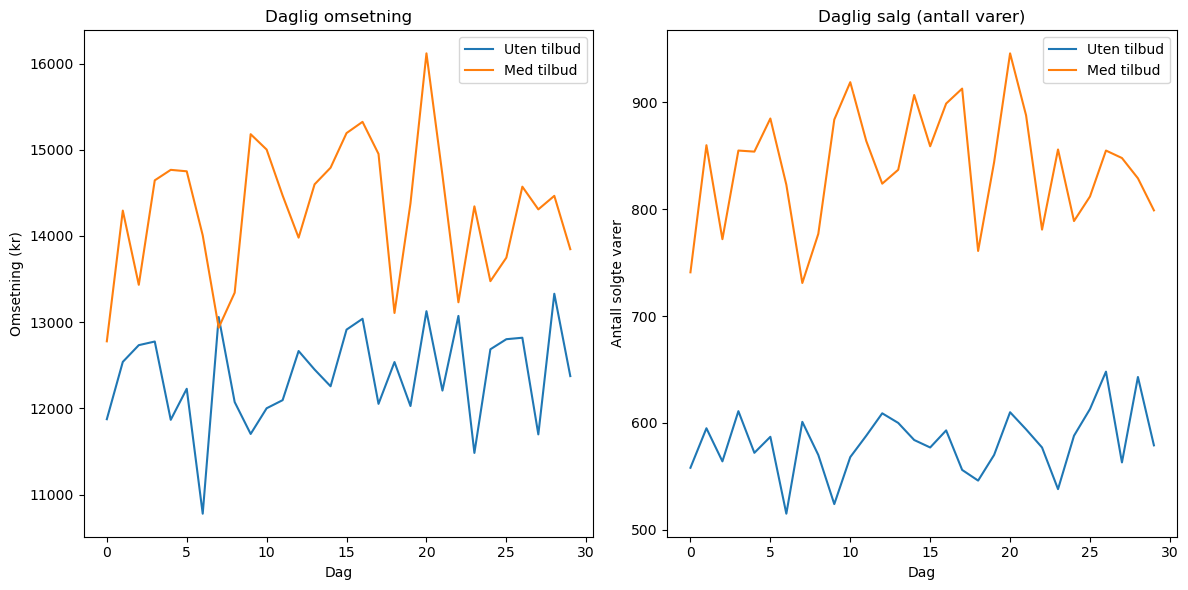

In [2]:
#Henter inn bibliotek
import random
import matplotlib.pyplot as plt

#Definer varer og priser
varer = {
    "Epler": 10.0,
    "Bananer": 15.0,
    "Krydder": 25.0,
    "Sjokolade": 12.0,
    "Melk": 20.0,
    "Rundstykker": 30.0,
    "Klubbe": 6.0,
    "Biff": 60.0
}

#Funksjon for å simulere en kundes handletur
def simuler_handling(budsjett, tilbud=False):   #Simulering av handling uten tilbud
    handlekurv = []
    total_pris = 0.0               #Definere startpunktet for totalpris
    solgte_varer = 0               #Definere startpunktet for solgte varer
    varenavn = list(varer.keys())  #Lager en liste av varene kunden kan kjøpe
    
    #Sluttsjanse for å avslutte shopping
    if tilbud:
        sluttsjanse = 0.05         #Lavere sannsynlighet for å slutte når det er tilbud
    else:
        sluttsjanse = 0.1          #Større sannsynlighet for å slutte når det ikke er tilbud

    shopper = True
    while shopper:
        vare = random.choice(varenavn) #Velger en tilfeldig vare ut av listen "varenavn"
        varepris = varer[vare]         #Gir prisen på en tilfeldig valgt vare
        if tilbud:
            varepris *= 0.8      #Hvis det er tilbud, så er det 20% avslag
        
        #Kjøp varen hvis den er innenfor budsjettet
        if budsjett > varepris:      #Hvis budsjettet er større en vareprisen, så fortsetter funksjonen
            handlekurv.append(vare)  #Legger inn den tilfeldige varen i en handlekurv
            total_pris += varepris   #Definerer at varepris skal være større eller lik total prisen
            solgte_varer += 1        #Definerer at solgte varer skal være mer eller lik 1
            budsjett -= varepris     #Definerer at varepris skal være mindre eller lik budsjettet
        else:
            shopper = False          #Når kriteriene ovenfor ikke stemmer, slutter kunden å handle, funksjonen slutter
        
        #Sjekk om kunden velger å avslutte handleturen
        if random.random() < sluttsjanse:
            shopper = False          #Hvis random er mindre enn sluttsjanse er kunden ferdig å handle
    
    return total_pris, solgte_varer  #Finner ut en kundes totale antall varer og hvor mye varene kostet til sammen

#Simulerer handlingen over en måned (30 dager)
def simuler_mnd(tilbud=False):     #Simulering av månedlig handel uten tilbud
    total_omsetning = []     #Definere total_omsetning som en tom liste
    total_salg = []          #Definere total_salg som en tom liste
    for dag in range(30):    #For-løkka kjøres 30 ganger for å få månedlig omsetning og salg
        daglig_omsetning = 0  #Definere startpunktet for daglig omsetning
        daglig_salg = 0       #Definere startpunktet for daglig salg
        for _ in range(100):  #100 kunder per dag
            budsjett = random.uniform(100, 300)  #Tilfeldig budsjett mellom 100 og 300
            omsetning, salg = simuler_handling(budsjett, tilbud) 
            daglig_omsetning += omsetning   #Definerer at omsetning skal være større eller lik daglig omsetning
            daglig_salg += salg             #Definerer at salg skal være større eller lik daglig salg
        total_omsetning.append(daglig_omsetning)   #Legger daglig omsetning inn i den totale omsetningen
        total_salg.append(daglig_salg)             #Legger daglig salg inn i det totale salget
    return total_omsetning, total_salg             #Får en liste av 30 dager med total omsetning og salg

#Simulering uten tilbud
omsetning_uten_tilbud, salg_uten_tilbud = simuler_mnd(tilbud=False)  #Definerer månedens omsetning og salg uten tilbud

#Simulering med tilbud
omsetning_med_tilbud, salg_med_tilbud = simuler_mnd(tilbud=True)    #Definerer månedens omsetning og salg med tilbud

#Plot resultater
plt.figure(figsize=(12, 6))       #Legger inn størrelsen på grafene

#Sammenligne omsetning
plt.subplot(1, 2, 1)    #legger inn en rad, 2 diagram, dette er første graf 
plt.plot(omsetning_uten_tilbud, label="Uten tilbud")  #Plotter inn grafen for månedlig omsetning uten tilbud
plt.plot(omsetning_med_tilbud, label="Med tilbud")    #Plotter inn grafen for månedlig omsetning med tilbud
plt.title("Daglig omsetning")    #Legger inn tittel på diagrammet
plt.xlabel("Dag")                #Legger inn tittel på x-aksen
plt.ylabel("Omsetning (kr)")     #Legger inn tittel på y-aksen
plt.legend()                     #For å navngi aksene

#Sammenligne salg
plt.subplot(1, 2, 2)   #Legger inn en rad, 2 diagram, dette er andre graf
plt.plot(salg_uten_tilbud, label="Uten tilbud")  #Plotter inn grafen for månedlig salg uten tilbud
plt.plot(salg_med_tilbud, label="Med tilbud")    #Plotter inn grafen for månedlig salg med tilbud
plt.title("Daglig salg (antall varer)")    #Legger til tittel på diagrammet
plt.xlabel("Dag")                          #Legger til tittel på x-aksen
plt.ylabel("Antall solgte varer")          #Legger til tittel på y-aksen
plt.legend()                               #For å navngi aksene

plt.tight_layout()      #Rydder opp diagrammene, og gjør at grafene og tittelene passer inn 
plt.show()              #Viser fram diagrammene

### Diskusjon/resultat